In [ ]:
!pip install yfinance
!pip install pandas
!pip install matplotlib
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

[*********************100%***********************]  1 of 1 completed


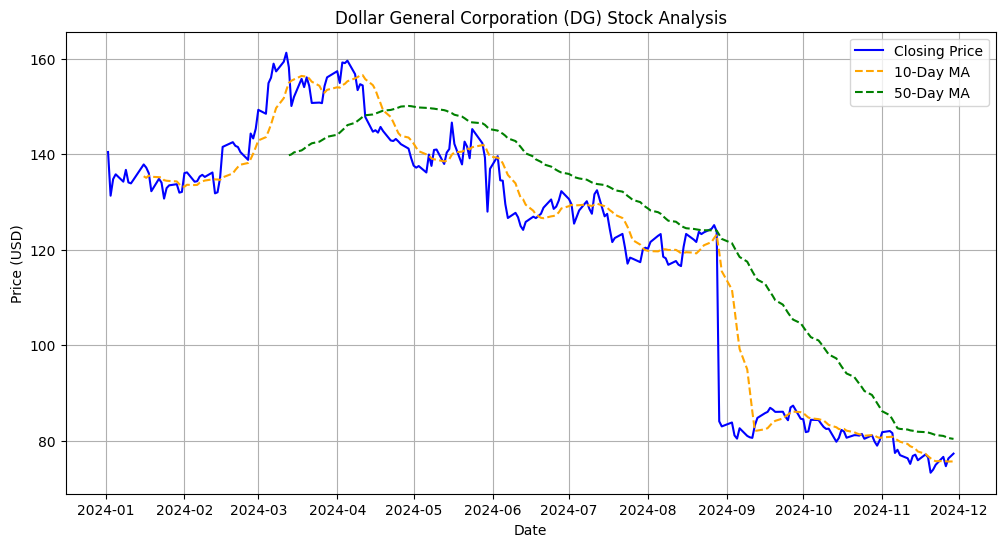

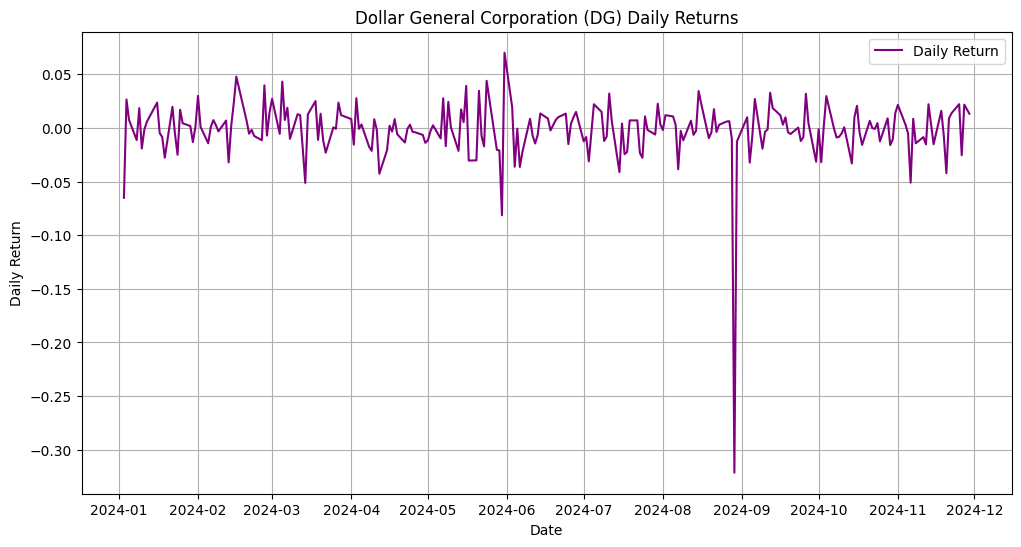

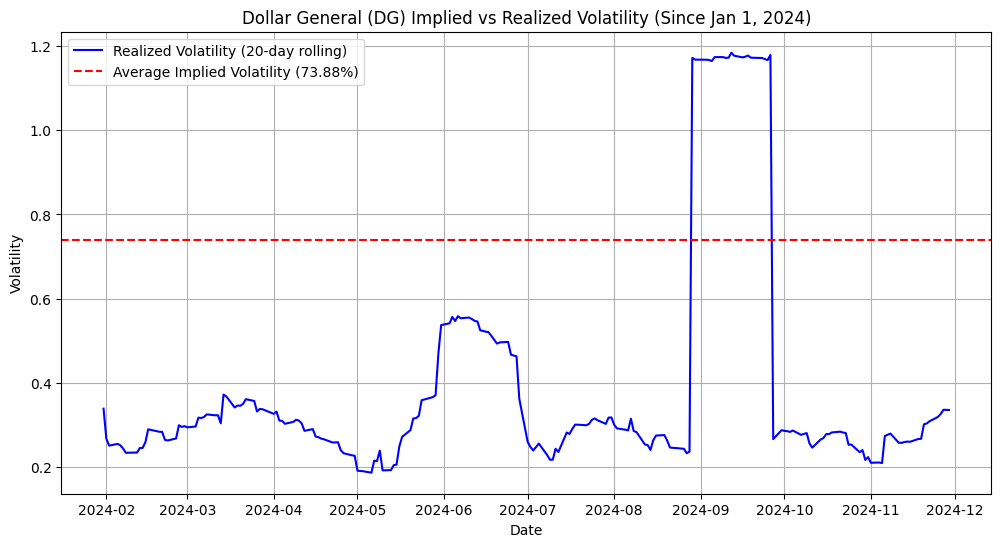

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

def fetch_dg_data(ticker='DG', start_date='2024-01-01', end_date='2024-12-01'):
    return yf.download(ticker, start=start_date, end=end_date)

def analyze_data(data):
    data['10-Day MA'] = data['Close'].rolling(window=10).mean()
    data['50-Day MA'] = data['Close'].rolling(window=50).mean()
    data['Daily Return'] = data['Close'].pct_change()
    data['Realized Volatility'] = data['Daily Return'].rolling(window=20).std() * (252 ** 0.5)
    return data

def fetch_implied_volatility(ticker='DG', start_date='2024-01-01'):
    option_chain = yf.Ticker(ticker)
    expirations = option_chain.options
    implied_volatility_df = []

    for expiration in expirations:
        try:
            options_data = option_chain.option_chain(expiration).calls
            options_data['expiration'] = expiration
            implied_volatility_df.append(options_data[['impliedVolatility', 'expiration']])
        except:
            continue

    implied_volatility = pd.concat(implied_volatility_df, ignore_index=True)
    implied_volatility['date'] = pd.to_datetime(start_date)
    implied_volatility.set_index('date', inplace=True)
    return implied_volatility['impliedVolatility'].mean()

def plot_data(data, avg_implied_vol):
    plt.figure(figsize=(12, 6))
    plt.plot(data['Close'], label='Closing Price', color='blue')
    plt.plot(data['10-Day MA'], label='10-Day MA', color='orange', linestyle='--')
    plt.plot(data['50-Day MA'], label='50-Day MA', color='green', linestyle='--')
    plt.title('Dollar General Corporation (DG) Stock Analysis')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(data['Daily Return'], label='Daily Return', color='purple')
    plt.title('Dollar General Corporation (DG) Daily Returns')
    plt.xlabel('Date')
    plt.ylabel('Daily Return')
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data['Realized Volatility'], label='Realized Volatility (20-day rolling)', color='blue')
    plt.axhline(y=avg_implied_vol, color='red', linestyle='--', label=f'Average Implied Volatility ({avg_implied_vol:.2%})')
    plt.title('Dollar General (DG) Implied vs Realized Volatility (Since Jan 1, 2024)')
    plt.xlabel('Date')
    plt.ylabel('Volatility')
    plt.legend()
    plt.grid()
    plt.show()

if __name__ == "__main__":
    start_date = '2024-01-01'
    end_date = '2024-12-01'
    dg_data = fetch_dg_data(start_date=start_date, end_date=end_date)
    dg_data = analyze_data(dg_data)
    avg_implied_vol = fetch_implied_volatility()
    dg_data['Implied Volatility'] = avg_implied_vol
    plot_data(dg_data, avg_implied_vol)


[*********************100%***********************]  1 of 1 completed


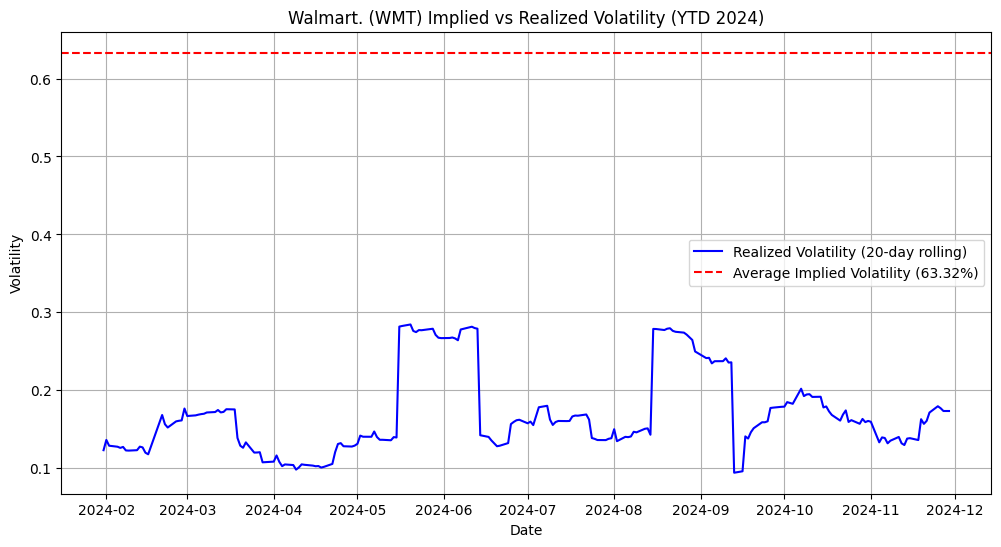

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

def fetch_kr_data(ticker='WMT', start_date='2024-01-01', end_date='2024-12-01'):
    return yf.download(ticker, start=start_date, end=end_date)

def calculate_realized_volatility(data, window=20):
    data['Daily Return'] = data['Close'].pct_change()
    data['Realized Volatility'] = data['Daily Return'].rolling(window=window).std() * (252 ** 0.5)
    return data

def fetch_implied_volatility(ticker='WMT', start_date='2024-01-01'):
    option_chain = yf.Ticker(ticker)
    expirations = option_chain.options
    implied_volatility_df = []
    for expiration in expirations:
        try:
            options_data = option_chain.option_chain(expiration).calls
            options_data['expiration'] = expiration
            implied_volatility_df.append(options_data[['impliedVolatility', 'expiration']])
        except:
            continue
    implied_volatility = pd.concat(implied_volatility_df, ignore_index=True)
    implied_volatility['date'] = pd.to_datetime(start_date)
    implied_volatility.set_index('date', inplace=True)
    return implied_volatility['impliedVolatility'].mean()

def plot_volatility(data, avg_implied_vol):
    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data['Realized Volatility'], label='Realized Volatility (20-day rolling)', color='blue')
    plt.axhline(y=avg_implied_vol, color='red', linestyle='--', label=f'Average Implied Volatility ({avg_implied_vol:.2%})')
    plt.title('Walmart. (WMT) Implied vs Realized Volatility (YTD 2024)')
    plt.xlabel('Date')
    plt.ylabel('Volatility')
    plt.legend()
    plt.grid()
    plt.show()

if __name__ == "__main__":
    start_date = '2024-01-01'
    end_date = '2024-12-01'
    kr_data = fetch_kr_data(start_date=start_date, end_date=end_date)
    kr_data = calculate_realized_volatility(kr_data)
    avg_implied_vol = fetch_implied_volatility()
    plot_volatility(kr_data, avg_implied_vol)


In [ ]:
ticker = "KR"
import yfinance as yf
import matplotlib.pyplot as plt
#data for the past year
data = yf.download(ticker, period="1y")
print(data)
plt.plot(data['Close'])
plt.title(f'{ticker} Stock Price (Past Year)')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.grid(True)
# Pandas has a couple of functions that can help with fixing NaN's.
#sklearn is another library that can help with data preprocessing.


SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (<ipython-input-1-1aa2dcead440>, line 17)

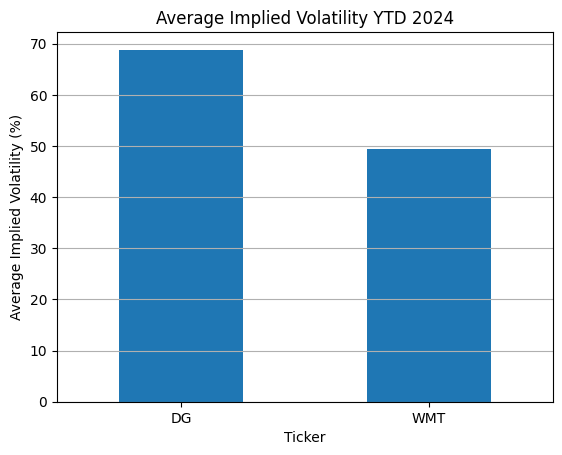

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

def fetch_implied_volatility(ticker, start_date='2024-01-01', end_date='2024-12-01'):
    ticker_obj = yf.Ticker(ticker)
    expirations = ticker_obj.options
    iv_values = []
    for expiration in expirations:
        try:
            options = ticker_obj.option_chain(expiration)
            calls = options.calls
            puts = options.puts
            iv_values.extend(calls['impliedVolatility'].dropna().tolist())
            iv_values.extend(puts['impliedVolatility'].dropna().tolist())
        except Exception as e:
            print(f"Error fetching data for {ticker} expiration {expiration}: {e}")
    if iv_values:
        avg_iv = sum(iv_values) / len(iv_values)
    else:
        avg_iv = None
    return avg_iv

if __name__ == "__main__":
    tickers = ['DG', 'WMT']
    avg_ivs = {}
    for ticker in tickers:
        avg_iv = fetch_implied_volatility(ticker)
        if avg_iv is not None:
            avg_ivs[ticker] = avg_iv * 100  # Convert to percentage
        else:
            avg_ivs[ticker] = None

    df = pd.DataFrame(list(avg_ivs.items()), columns=['Ticker', 'Average Implied Volatility'])
    df.set_index('Ticker', inplace=True)
    df.plot(kind='bar', legend=False)
    plt.ylabel('Average Implied Volatility (%)')
    plt.title('Average Implied Volatility YTD 2024')
    plt.xticks(rotation=0)
    plt.grid(axis='y')
    plt.show()


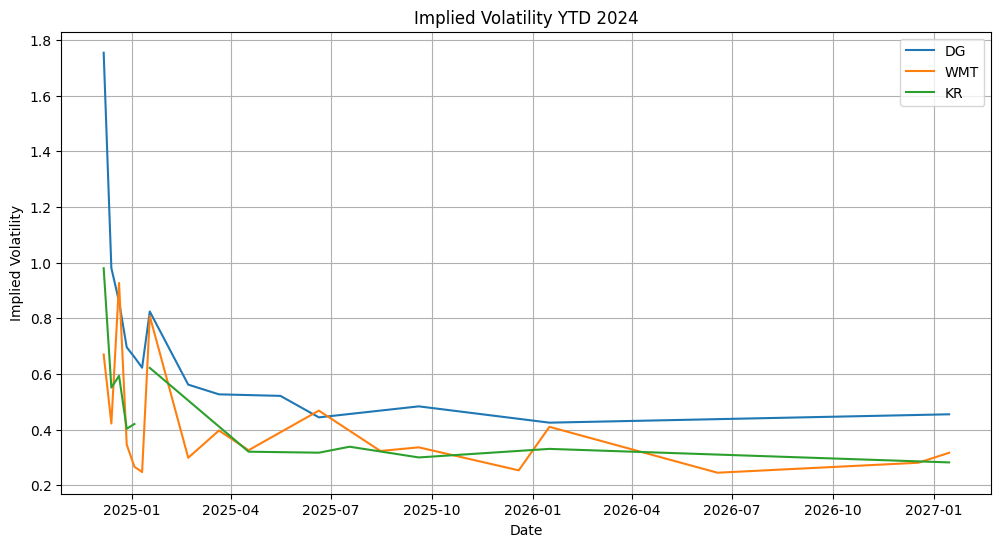

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

def fetch_implied_volatility_over_time(ticker, start_date='2024-01-01', end_date='2024-12-01'):
    ticker_obj = yf.Ticker(ticker)
    expirations = ticker_obj.options
    iv_data = []



    for expiration in expirations:
        try:
            options = ticker_obj.option_chain(expiration)
            calls = options.calls
            puts = options.puts
            avg_iv = (calls['impliedVolatility'].mean() + puts['impliedVolatility'].mean()) / 2
            iv_data.append({'Date': pd.to_datetime(expiration), 'IV': avg_iv})
        except Exception as e:
            print(f"Error fetching data for {ticker} expiration {expiration}: {e}")

    iv_df = pd.DataFrame(iv_data)
    iv_df = iv_df.sort_values(by='Date')
    return iv_df

if __name__ == "__main__":
    tickers = ['DG', 'WMT', 'KR']
    iv_dfs = {}

    for ticker in tickers:
        iv_dfs[ticker] = fetch_implied_volatility_over_time(ticker)

    plt.figure(figsize=(12, 6))
    for ticker, iv_df in iv_dfs.items():
        if not iv_df.empty:
            plt.plot(iv_df['Date'], iv_df['IV'], label=ticker)

    plt.title('Implied Volatility YTD 2024')
    plt.xlabel('Date')
    plt.ylabel('Implied Volatility')
    plt.legend()
    plt.grid()
    plt.show()


In [ ]:
 df.head()

,Average Implied Volatility
Ticker,
DG,0.919497
WMT,0.555681
KR,0.571444


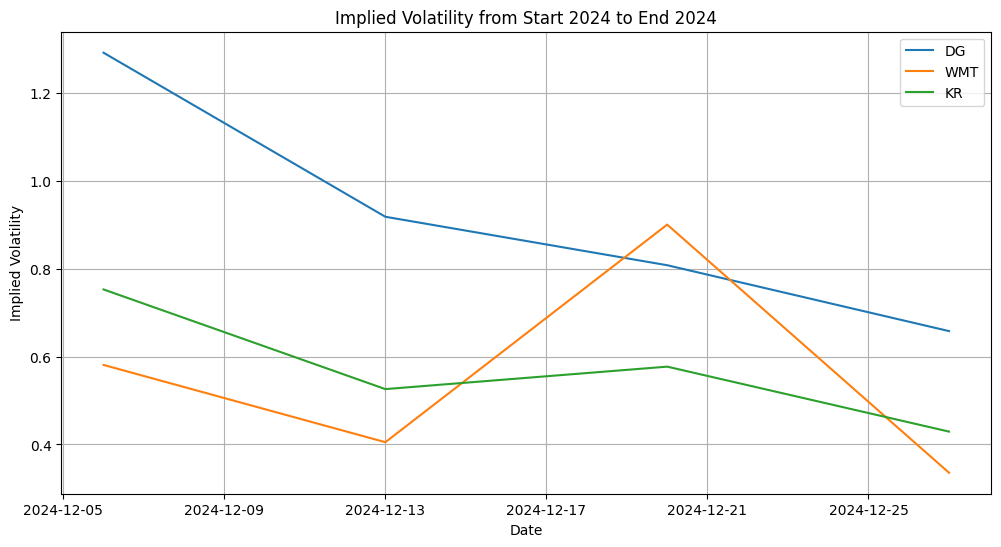

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import datetime

def fetch_implied_volatility_over_time(ticker, start_date='2024-01-01', end_date='2024-12-31'):
    ticker_obj = yf.Ticker(ticker)
    expirations = ticker_obj.options

    # Filter expirations to be within the desired date range
    start_date_dt = datetime.datetime.strptime(start_date, '%Y-%m-%d').date()
    end_date_dt = datetime.datetime.strptime(end_date, '%Y-%m-%d').date()
    filtered_expirations = [exp for exp in expirations if start_date_d



                            t <= datetime.datetime.strptime(exp, '%Y-%m-%d').date() <= end_date_dt]

    iv_data = []
    for expiration in filtered_expirations:
        try:
            options = ticker_obj.option_chain(expiration)
            calls = options.calls
            puts = options.puts
            avg_iv = (calls['impliedVolatility'].mean() + puts['impliedVolatility'].mean()) / 2
            iv_data.append({'Date': pd.to_datetime(expiration), 'IV': avg_iv})
        except Exception as e:
            print(f"Error fetching data for {ticker} expiration {expiration}: {e}")

    iv_df = pd.DataFrame(iv_data)
    iv_df = iv_df.sort_values(by='Date')
    return iv_df

if __name__ == "__main__":
    tickers = ['DG', 'WMT', 'KR']
    iv_dfs = {}

    for ticker in tickers:
        iv_dfs[ticker] = fetch_implied_volatility_over_time(ticker)

    plt.figure(figsize=(12, 6))
    for ticker, iv_df in iv_dfs.items():
        if not iv_df.empty:
            plt.plot(iv_df['Date'], iv_df['IV'], label=ticker)

    plt.title('Implied Volatility from Start 2024 to End 2024')
    plt.xlabel('Date')
    plt.ylabel('Implied Volatility')
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
df.head()

NameError: name 'df' is not defined